In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.optim import Adam
from torch.utils.data import DataLoader


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [2]:
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 8.86MB/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 138kB/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 2.58MB/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 7.68MB/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



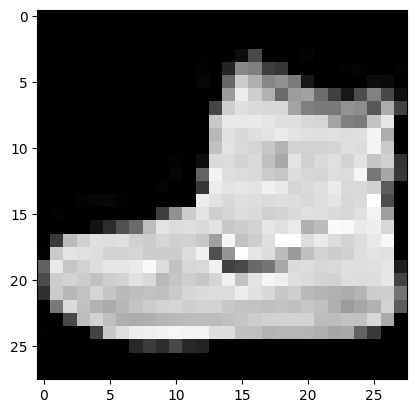

In [3]:
plt.imshow(training_data[0][0][0, :, :], cmap='gray')

In [9]:
training_images = [t[0] for t in training_data]

In [10]:
training_images = torch.stack(training_images)

In [11]:
training_images.shape
training_images = training_images*2 - 1

In [12]:
data = DataLoader(training_images, batch_size=64, shuffle=True)

# The Actual Diffusion

In [13]:
T = 1000
betas = torch.linspace(0.0001, 0.02, T)
alphas = 1 - betas
alphas_bar = torch.cumprod(alphas, 0, dtype=torch.float64)



In [14]:
import math

def positionalencoding2d(d_model, height, width):
    """
    :param d_model: dimension of the model
    :param height: height of the positions
    :param width: width of the positions
    :return: d_model*height*width position matrix
    """
    if d_model % 4 != 0:
        raise ValueError("Cannot use sin/cos positional encoding with "
                         "odd dimension (got dim={:d})".format(d_model))
    pe = torch.zeros(d_model, height, width)
    # Each dimension use half of d_model
    d_model = int(d_model / 2)
    div_term = torch.exp(torch.arange(0., d_model, 2) *
                         -(math.log(10000.0) / d_model))
    pos_w = torch.arange(0., width).unsqueeze(1)
    pos_h = torch.arange(0., height).unsqueeze(1)
    pe[0:d_model:2, :, :] = torch.sin(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[1:d_model:2, :, :] = torch.cos(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[d_model::2, :, :] = torch.sin(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)
    pe[d_model + 1::2, :, :] = torch.cos(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)

    return pe


embeddings = positionalencoding2d(T, 28, 28)

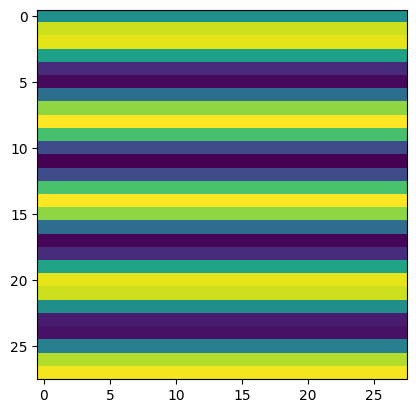

In [15]:
plt.imshow(embeddings[500, :, :])

In [ ]:
class Unet(nn.Module):
    def __init__(self, c=16):
        super().__init__()

        self.conv1 = nn.Conv2d(2, c, 12)
        self.conv2 = nn.Conv2d(c, c*2, 7)
        self.conv3 = nn.Conv2d(c*2, c*4, 3)
        self.conv4 = nn.Conv2d(c*4,c*8,2)

        self.convt4 = nn.ConvTranspose2d(c*8,c*4,2)
        self.convt3 = nn.ConvTranspose2d(c*4, c*2, 3)
        self.convt2 = nn.ConvTranspose2d(c*2, c, 7)
        self.convt1 = nn.ConvTranspose2d(c, 1, 12)

        self.acts = [nn.LeakyReLU(0.2) for _ in range(7)]

    def forward(self, x, t):
        c1 = self.conv1(torch.stack((x, t), axis=1).view(x.shape[0], 2, 28, 28))
        c1 = self.acts[0](c1)
        c2 = self.conv2(c1)
        c2 = self.acts[1](c2)
        c3 = self.conv3(c2)
        c3 = self.acts[2](c3)
        c4 = self.conv4(c3)
        c4 = self.acts[3](c4)

        o4 = self.convt4(c4) + c3
        o4 = self.acts[4](o4)
        o3 = self.convt3(c3) + c2
        o3 = self.acts[5](o3)
        o2 = self.convt2(o3) + c1
        o2 = self.acts[6](o2)
        o1 = self.convt1(o2)

        return o1 + x

model = Unet(64)
optimizer = Adam(model.parameters(), lr=0.0005)
model = model.to(device)
criterion = nn.L1Loss()
pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(pytorch_total_params)
mean_losses = []

In [ ]:

for epoch in range(30):
    total_loss = 0
    n_losses = len(data)
    mean_loss = 0
    for i, batch in enumerate(data):
        x = batch.to(device)
        t = torch.randint(0, T, (x.size(0),), device='cpu').long()
        alphas_bar_t = alphas_bar[t].view(-1, 1, 1, 1).to(device)
        noise = torch.randn_like(x) # epsilon nel paper
        noisy_images = (torch.sqrt(alphas_bar_t) * x + torch.sqrt(1 - alphas_bar_t) * noise).float()
        t_embs = embeddings[t]
        t_embs = t_embs.view(t_embs.shape[0], 1, t_embs.shape[1], t_embs.shape[2]).to(device)
        y = model(noisy_images, t_embs)
        optimizer.zero_grad()
        loss = criterion(y, noise)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    mean_loss = total_loss/n_losses
    print(epoch, mean_loss)
    mean_losses.append(mean_loss)
    #print(epoch, loss.item())

In [ ]:
plt.plot(mean_losses)

In [ ]:
def imshow(x):
    plt.imshow(x[0][0].cpu().numpy())
    plt.show()

In [ ]:
with torch.no_grad():
    # Start from pure noise:
    x = torch.randn((1, 1, 28, 28), device=device)
    
    for t in reversed(range(1, T)):
        # Get the time embedding for step t
        time_emb = embeddings[t].view(1, 1, 28, 28).to(device)
        
        # Predict the noise component for the current sample and timestep
        predicted_noise = model(x, time_emb)
        
        # Get current parameters from the noise schedule:
        alpha_t = alphas[t]            # scalar or tensor of shape [1] 
        alpha_bar_t = alphas_bar[t]      # cumulative product up to t
        alpha_bar_t_1 = alphas_bar[t-1]      # cumulative product up to t

        beta_t = betas[t]                # variance for step t
        
        # Compute the reverse process mean
        x_mean = (1.0 / torch.sqrt(alpha_t)) * (
                  x - (torch.sqrt(1 - alpha_bar_t) * predicted_noise)
                 )  + torch.sqrt(1 - alpha_bar_t_1)#*predicted_noise
        
        if t > 1:
            # Add noise for stochasticity in reverse process:
            noise = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = x_mean + sigma_t * noise
        else:
            x = x_mean  # final step, no noise added

In [ ]:
with torch.no_grad():
    # Start from pure noise:
    x = torch.randn((1, 1, 28, 28), device=device)
    
    for t in reversed(range(1, T)):
        # Get the time embedding for step t
        time_emb = embeddings[t].view(1, 1, 28, 28).to(device)
        
        # Predict the noise component for the current sample and timestep
        predicted_noise = model(x, time_emb)
        
        # Get current parameters from the noise schedule:
        alpha_t = alphas[t]            # scalar or tensor of shape [1] 
        alpha_bar_t = alphas_bar[t]      # cumulative product up to t
        beta_t = betas[t]                # variance for step t
        
        # Compute the reverse process mean
        x_mean = (1.0 / torch.sqrt(alpha_t)) * (
                  x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * predicted_noise
                 )        
        if t > 1:
            # Add noise for stochasticity in reverse process:
            noise = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = x_mean + sigma_t * noise
        else:
            x = x_mean  # final step, no noise added

In [ ]:
x.mean()

In [ ]:
with torch.no_grad():
    plt.imshow(x[0][0].cpu().numpy(), cmap='gray')
    plt.show()